## Check Model Saving dict keys 

In [1]:
import torch
checkpoint = torch.load("/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/best.pt", map_location="cpu")
print(type(checkpoint))

# If it's a dict, check the keys
if isinstance(checkpoint, dict):
    print(checkpoint.keys())

<class 'dict'>
dict_keys(['epoch', 'model_state', 'optimizer_state', 'best_fsr'])


## Conver the .pt file to onnx file

In [2]:
import sys
import torch
import onnx
import onnxruntime as ort
import numpy as np

# ── Step 1: Add source directories ────────────────────────────────────────────
sys.path.insert(0, "/inwdata2a/sudhanshu/Unet_training_script")

from models.unet_encoder_model import MouthLandmarkModel
from src.utils import load_unet_segmentation_model

# ── Step 2: Load checkpoint and restore weights ────────────────────────────────
checkpoint_path = "/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/best.pt"
onnx_output_path = "/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/best.onnx"

print(f"[INFO] Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location="cpu")

print(f"[INFO] Checkpoint epoch: {checkpoint['epoch']}, best_fsr: {checkpoint['best_fsr']}")

# ── Step 3: Build model and load weights ───────────────────────────────────────
pretrain_path = "/inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt"
backbone = load_unet_segmentation_model(pretrain_path)

model = MouthLandmarkModel(
    backbone      = backbone,
    num_landmarks = 4
)

model.load_state_dict(checkpoint["model_state"])
model.eval()
print("[INFO] Model weights loaded and set to eval mode ✅")

# ── Step 4: Wrapper to convert dict output → tuple (required for ONNX) ────────
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        output = self.model(x)
        return output["heatmaps"], output["coords"]

wrapped_model = ModelWrapper(model)
wrapped_model.eval()

# ── Step 5: Dummy input ────────────────────────────────────────────────────────
dummy_input = torch.randn(1, 1, 128, 128)  # batch=1, channel=1, H=128, W=128

# ── Step 6: Export to ONNX ────────────────────────────────────────────────────
print(f"[INFO] Exporting to ONNX: {onnx_output_path}")
torch.onnx.export(
    wrapped_model,
    dummy_input,
    onnx_output_path,
    export_params    = True,
    opset_version    = 17,
    do_constant_folding = True,
    input_names      = ["input"],
    output_names     = ["heatmaps", "coords"],
    dynamic_axes     = {
        "input":    {0: "batch_size"},
        "heatmaps": {0: "batch_size"},
        "coords":   {0: "batch_size"},
    }
)
print(f"[INFO] ONNX model saved to: {onnx_output_path} ✅")

# ── Step 7: Verify ONNX model ─────────────────────────────────────────────────
onnx_model = onnx.load(onnx_output_path)
onnx.checker.check_model(onnx_model)
print("[INFO] ONNX model check passed ✅")

# ── Step 8: Quick inference check with ONNXRuntime ────────────────────────────
ort_session = ort.InferenceSession(onnx_output_path, providers=["CPUExecutionProvider"])

dummy_np    = dummy_input.numpy()
ort_outputs = ort_session.run(None, {"input": dummy_np})

print("heatmaps shape:", ort_outputs[0].shape)  # expected: [1, 4, 128, 128]
print("coords shape:  ", ort_outputs[1].shape)  # expected: [1, 4, 2] or similar
print("[INFO] ONNXRuntime inference verified ✅")

[INFO] Loading checkpoint from: /inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/best.pt
[INFO] Checkpoint epoch: 80, best_fsr: 0.5578293163559194
---unet segmentor with upsample layers---
NUM PARAMS = 66761

[INFO] Loaded and set UnetUpSample_modified to train mode from: /inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt
[INFO] Total trainable params: 66761
[INFO] MouthLandmarkModel created
[INFO] Total params: 80781  |  Trainable: 80781
[INFO] Model weights loaded and set to eval mode ✅
[INFO] Exporting to ONNX: /inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/best.onnx


/tmp/ipykernel_57725/3412894829.py:53: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


[INFO] ONNX model saved to: /inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/best.onnx ✅
[INFO] ONNX model check passed ✅
heatmaps shape: (1, 4, 128, 128)
coords shape:   (1, 4, 2)
[INFO] ONNXRuntime inference verified ✅


## Infer the onnx on one mouth crop

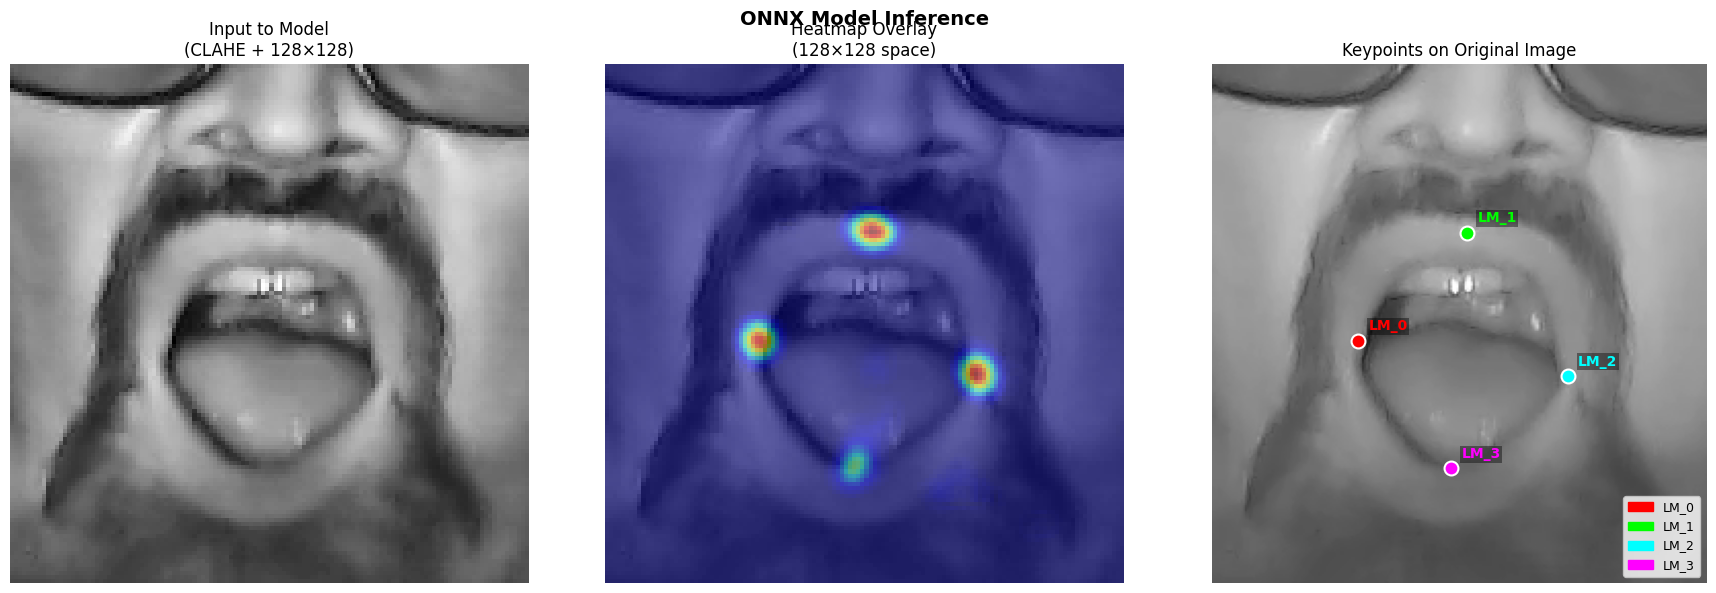

[INFO] Saved → /inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/onnx_inference_final.png ✅


In [5]:
import numpy as np
import onnxruntime as ort
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Config ────────────────────────────────────────────────────────────────────
image_path = "/inwdata2a/sudhanshu/mouth_keypoints/mouth_crops_v2/0a98dc24-d808-43fd-9864-9db090467dd9_000318.png"
onnx_path  = "/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/best.onnx"
output_path = "/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/onnx_inference_final.png"

MEAN           = 0.485
STD            = 0.229
INPUT_SIZE     = 128
landmark_names  = ["LM_0", "LM_1", "LM_2", "LM_3"]
landmark_colors = ["red", "lime", "cyan", "magenta"]

# ── Step 1: Load image ────────────────────────────────────────────────────────
img_bgr  = cv2.imread(image_path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
original_h, original_w = img_gray.shape

# ── Step 2: CLAHE ─────────────────────────────────────────────────────────────
clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

# ── Step 3: Resize → Normalize → Tensorize ────────────────────────────────────
img_resized = cv2.resize(img_clahe, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_LINEAR)
img_norm    = (img_resized / 255.0 - MEAN) / STD
img_tensor  = img_norm.astype(np.float32)[np.newaxis, np.newaxis, :, :]  # (1,1,128,128)

# ── Step 4: ONNX Inference ────────────────────────────────────────────────────
ort_session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
heatmaps, coords = ort_session.run(None, {"input": img_tensor})
# heatmaps: (1, 4, 128, 128) | coords: (1, 4, 2) normalized [0,1]

# ── Step 5: Scale coords [0,1] → original image pixel space ──────────────────
coords_px = coords[0].copy()           # (4, 2)
coords_px[:, 0] *= original_w          # x
coords_px[:, 1] *= original_h          # y

# ── Step 6: Plot ──────────────────────────────────────────────────────────────
img_display = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

heatmap_sum = heatmaps[0].sum(axis=0)
heatmap_sum = (heatmap_sum - heatmap_sum.min()) / (heatmap_sum.max() - heatmap_sum.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("ONNX Model Inference", fontsize=14, fontweight="bold")

# Left: model input
axes[0].imshow(img_resized, cmap="gray")
axes[0].set_title("Input to Model\n(CLAHE + 128×128)")
axes[0].axis("off")

# Middle: heatmap overlay
axes[1].imshow(img_resized, cmap="gray")
axes[1].imshow(heatmap_sum, cmap="jet", alpha=0.5)
axes[1].set_title("Heatmap Overlay\n(128×128 space)")
axes[1].axis("off")

# Right: keypoints on original image
axes[2].imshow(img_display)
for i, (x, y) in enumerate(coords_px):
    axes[2].plot(x, y, "o",
                 color=landmark_colors[i], markersize=10,
                 markeredgecolor="white", markeredgewidth=1.5)
    axes[2].text(x + 5, y - 5, landmark_names[i],
                 color=landmark_colors[i], fontsize=10, fontweight="bold",
                 bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none"))

legend_patches = [
    mpatches.Patch(color=landmark_colors[i], label=landmark_names[i])
    for i in range(len(coords_px))
]
axes[2].legend(handles=legend_patches, loc="lower right", fontsize=9)
axes[2].set_title("Keypoints on Original Image")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[INFO] Saved → {output_path} ✅")

## Generate labeles csv for bheshaj

In [2]:
#!/usr/bin/env python3
"""
Inference script: runs mouth landmark model on test CSV,
saves predictions as DMS-frame pixel coordinates.

Output CSV columns:
  path_to_dms_frame | mouth_landmarks  (flat: x1,y1,x2,y2,...)
"""

import os
from pathlib import Path
import sys
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import pandas as pd

sys.path.insert(0, "/inwdata2a/sudhanshu/Unet_training_script")
# ── path setup (same as your other scripts) ───────────────────────────────────
THIS_FILE    = Path("__file__").resolve()
PROJECT_ROOT = THIS_FILE.parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset    import MouthDataset
from src.transforms import build_val_transforms
from src.utils      import (
    load_config, load_checkpoint, ensure_dir,
    load_unet_segmentation_model
)
from models.unet_encoder_model import MouthLandmarkModel

# ── CONFIG — edit these ───────────────────────────────────────────────────────
CHECKPOINT = "/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/best.pt"
CONFIG     = "/inwdata2a/sudhanshu/Unet_training_script/configs/default.yaml"
OUT_CSV    = "/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op_temp/predictions_dms.csv"
LIMIT      = None   # set to int e.g. 200 to process only first N samples

# ── HELPERS ───────────────────────────────────────────────────────────────────

def denormalize_landmarks(lm_norm: torch.Tensor, mouth_bbox: torch.Tensor):
    """[0,1] normalized → face crop pixel space"""
    x1, y1, x2, y2 = mouth_bbox.tolist()
    bw = max(1.0, x2 - x1 + 1)
    bh = max(1.0, y2 - y1 + 1)
    return [(xn * bw + x1, yn * bh + y1)
            for xn, yn in lm_norm.tolist()]


def landmarks_to_dms_frame(landmarks_face_crop, face_bbox: torch.Tensor):
    """face crop pixel space → full DMS frame pixel space"""
    fx1, fy1, _, _ = face_bbox.tolist()
    return [(x + fx1, y + fy1) for x, y in landmarks_face_crop]


def landmarks_to_flat_str(landmarks_dms):
    """[(x1,y1),(x2,y2),...] → 'x1,y1,x2,y2,...' """
    coords = []
    for x, y in landmarks_dms:
        coords.extend([f"{x:.4f}", f"{y:.4f}"])
    return ",".join(coords)


# ── SETUP ─────────────────────────────────────────────────────────────────────
cfg    = load_config(CONFIG)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pretrain_path = cfg['model']['pretrain_encoder_ckpt']
backbone      = load_unet_segmentation_model(pretrain_path, device=device)

model = MouthLandmarkModel(
    backbone=backbone,
    num_landmarks=int(cfg['data']['num_landmarks']),
).to(device)

ckpt = load_checkpoint(CHECKPOINT, map_location=device)
model.load_state_dict(ckpt['model_state'], strict=False)
model.eval()
print(f"[INFO] Loaded checkpoint : {CHECKPOINT}")

# ── DATASET ───────────────────────────────────────────────────────────────────
dataset = MouthDataset(
    csv_path  = cfg['paths']['test_csv'],
    cfg       = cfg,
    transform = build_val_transforms(cfg),
    is_train  = False
)
if LIMIT is not None:
    dataset.valid_indices = dataset.valid_indices[:LIMIT]

loader = DataLoader(
    dataset,
    batch_size  = int(cfg['training']['batch_size']),
    shuffle     = False,
    num_workers = int(cfg['training']['num_workers']),
    pin_memory  = True
)
print(f"[INFO] Running inference on {len(dataset)} samples")

# ── INFERENCE LOOP ────────────────────────────────────────────────────────────
rows = []

for batch in tqdm(loader, desc="Predicting"):
    img          = batch['image'].to(device)       # [B, 1, H, W]
    mask         = batch['mask']                   # [B, L]
    mouth_bboxes = batch['bbox']                   # [B, 4] mouth bbox in face crop space
    face_bboxes  = batch['face_bbox']              # [B, 4] face bbox in DMS frame space
    img_paths    = batch['img_path']               # list of B paths

    with torch.no_grad():
        out       = model(img)
        pred_norm = out['coords'].cpu()            # [B, L, 2] normalized [0,1]

    for i in range(img.shape[0]):
        # skip samples with no valid landmarks
        if mask[i].sum() == 0:
            continue

        mouth_bbox = mouth_bboxes[i]   # [4]
        face_bbox  = face_bboxes[i]    # [4]
        pred_lm    = pred_norm[i]      # [L, 2]

        # normalized → face crop space → DMS frame space
        pred_face_crop = denormalize_landmarks(pred_lm, mouth_bbox)
        pred_dms       = landmarks_to_dms_frame(pred_face_crop, face_bbox)

        rows.append({
            "path_to_dms_frame" : img_paths[i],
            "mouth_landmarks"   : landmarks_to_flat_str(pred_dms),
        })

# ── SAVE ──────────────────────────────────────────────────────────────────────
out_df = pd.DataFrame(rows, columns=["path_to_dms_frame", "mouth_landmarks"])
ensure_dir(os.path.dirname(OUT_CSV))
out_df.to_csv(OUT_CSV, index=False)

print(f"[INFO] Saved {len(out_df)} rows → {OUT_CSV}")
out_df.head()

---unet segmentor with upsample layers---
NUM PARAMS = 66761

[INFO] Loaded and set UnetUpSample_modified to train mode from: /inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt
[INFO] Total trainable params: 66761
[INFO] MouthLandmarkModel created
[INFO] Total params: 80781  |  Trainable: 80781
[INFO] Loaded checkpoint : /inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op/best.pt
[INFO] Running inference on 63401 samples


Predicting: 100%|██████████| 1982/1982 [05:29<00:00,  6.02it/s]


[INFO] Saved 62902 rows → /inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op_temp/predictions_dms.csv


,path_to_dms_frame,mouth_landmarks
0,/inwdata2a/sudhanshu/mouth_keypoints/mouth_fra...,"250.8432,684.4470,318.8506,647.6377,387.5145,6..."
1,/inwdata2a/sudhanshu/mouth_keypoints/mouth_fra...,"250.8432,684.4470,318.8506,647.6377,387.5145,6..."
2,/inwdata2a/sudhanshu/mouth_keypoints/mouth_fra...,"251.0235,679.9635,320.9597,645.3532,384.0155,6..."
3,/inwdata2a/sudhanshu/mouth_keypoints/mouth_fra...,"254.3092,680.2845,322.0265,644.8324,382.3257,6..."
4,/inwdata2a/sudhanshu/mouth_keypoints/mouth_fra...,"254.6128,673.1187,315.8586,641.5799,377.9628,6..."


[INFO] Total rows: 62902


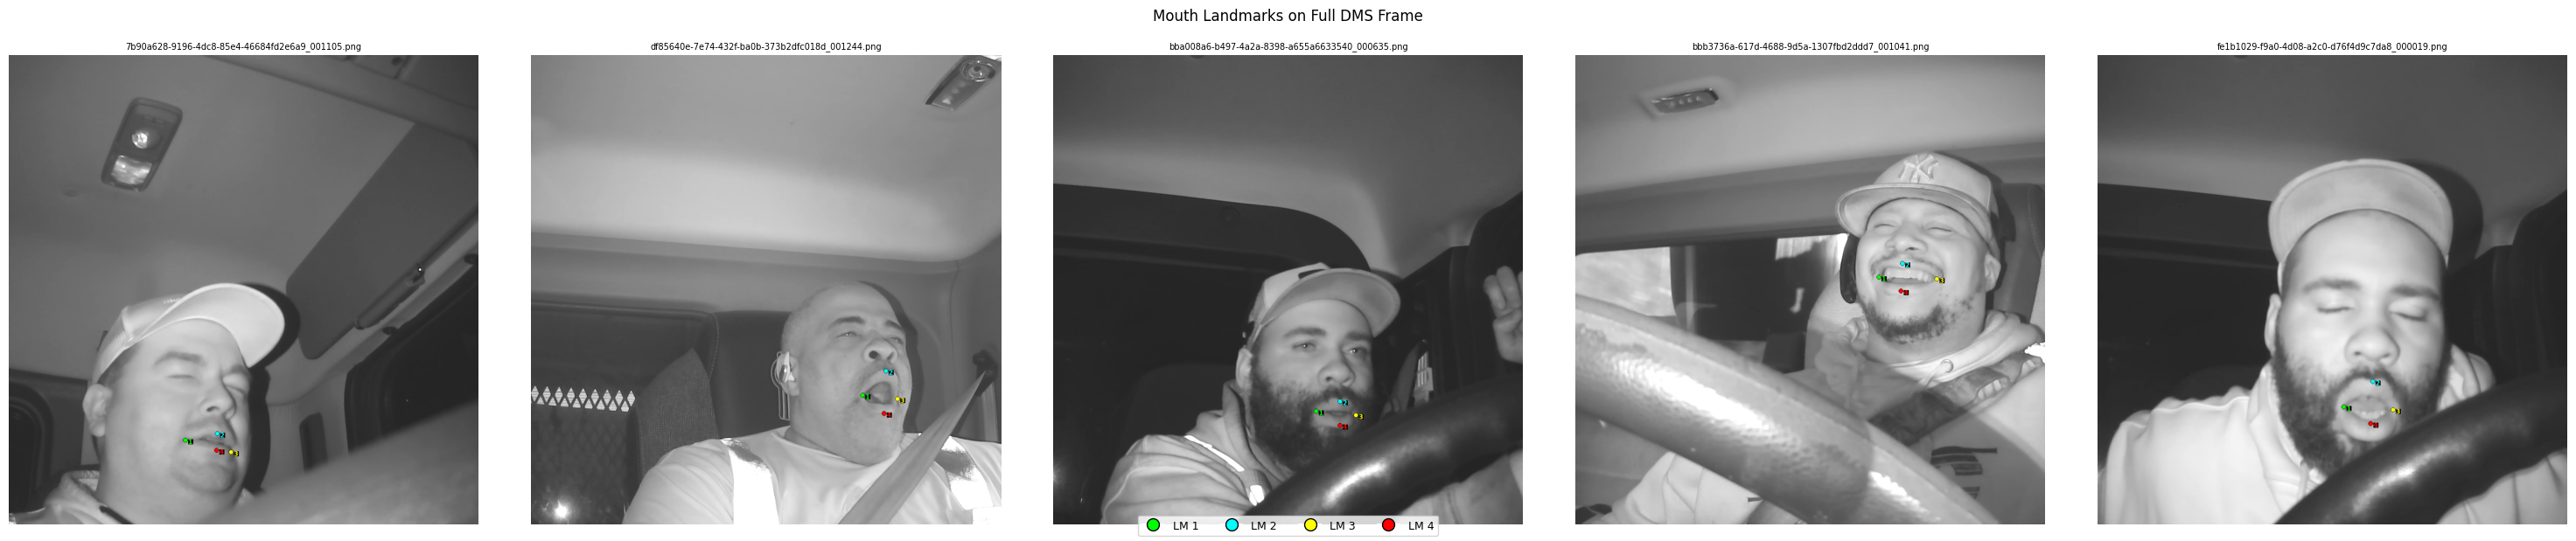

[INFO] Saved 5 annotated frames to: /inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op_temp/verify_dms_full/


In [ ]:
# ── VERIFY: overlay landmarks on full DMS frame ───────────────────────────────

import os
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import pandas as pd
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
CSV_PATH    = "/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op_temp/predictions_dms.csv"
SAVE_DIR    = "/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op_temp/verify_dms_full/"
NUM_SAMPLES = 5
DOT_RADIUS  = 6
FONT_SIZE   = 18

os.makedirs(SAVE_DIR, exist_ok=True)

# ── HELPERS ───────────────────────────────────────────────────────────────────
def parse_landmarks(lm_str):
    """'x1,y1,x2,y2,...' → [(x1,y1),(x2,y2),...]"""
    vals = [float(v) for v in lm_str.split(",")]
    return [(vals[i], vals[i+1]) for i in range(0, len(vals), 2)]

COLORS = [
    (0,   255,   0),   # LM1 — lime
    (0,   255, 255),   # LM2 — cyan
    (255, 255,   0),   # LM3 — yellow
    (255,   0,   0),   # LM4 — red
]

# ── LOAD & SAMPLE ─────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f"[INFO] Total rows: {len(df)}")
sample_df = df.sample(n=min(NUM_SAMPLES, len(df))).reset_index(drop=True)

# ── DRAW & DISPLAY FULL DMS FRAME ────────────────────────────────────────────
fig, axes = plt.subplots(1, NUM_SAMPLES, figsize=(6 * NUM_SAMPLES, 6))
if NUM_SAMPLES == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img_path = row['path_to_dms_frame']
    lms      = parse_landmarks(row['mouth_landmarks'])

    # ── open full DMS frame and draw on it ────────────────────────────────────
    full_img = Image.open(img_path).convert("RGB")
    draw     = ImageDraw.Draw(full_img)

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", FONT_SIZE)
    except:
        font = ImageFont.load_default()

    for idx, (x, y) in enumerate(lms):
        x, y  = int(round(x)), int(round(y))
        color = COLORS[idx % len(COLORS)]
        r     = DOT_RADIUS

        # filled circle with black outline
        draw.ellipse([(x - r, y - r), (x + r, y + r)],
                     fill=color, outline=(0, 0, 0), width=1)

        # numbered label with dark background
        label = str(idx + 1)
        bbox  = draw.textbbox((x + r + 2, y - r), label, font=font)
        draw.rectangle(bbox, fill=(0, 0, 0))
        draw.text((x + r + 2, y - r), label, fill=color, font=font)

    # # ── save full annotated DMS frame ─────────────────────────────────────────
    # save_name = Path(img_path).stem + "_landmarks.png"
    # save_path = os.path.join(SAVE_DIR, save_name)
    # full_img.save(save_path)

    # ── display full frame in notebook ────────────────────────────────────────
    ax.imshow(full_img)
    ax.axis('off')
    ax.set_title(Path(img_path).name, fontsize=7)

# ── legend ────────────────────────────────────────────────────────────────────
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=[c/255 for c in COLORS[i]],
               markersize=10, markeredgecolor='black',
               label=f'LM {i+1}')
    for i in range(len(COLORS))
]
fig.legend(handles=handles, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.8)

plt.suptitle("Mouth Landmarks on Full DMS Frame", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print(f"[INFO] Saved {NUM_SAMPLES} annotated frames to: {SAVE_DIR}")